# 🥈 02 — Silver Layer (Bronze → Silver)

**Pipeline:** IBM Cloud Object Storage · Medallion Architecture  
**Autor:** Federico Pfund  
**Fecha:** Abril 2026  

---

## Objetivo

Leer las tablas **Bronze** (Parquet en `datalake-bronze-us-south`), aplicar transformaciones de negocio y persistir
en el bucket **Silver** (`datalake-silver-us-south`).

### Transformaciones Aplicadas

| Tipo | Detalle |
|------|---------|
| **Joins** | Enriquecimiento dimensional (producto + subcategoría + categoría) |
| **Métricas financieras** | Ingreso bruto, costo total, margen, ganancia neta |
| **Clasificación logística** | Tipo de envío (Express / Standard / Delayed) |
| **Agregaciones temporales** | Resumen mensual de ventas por categoría |
| **Rentabilidad** | Análisis de margen y volumen por producto |
| **Segmentación RFM** | Recency, Frequency, Monetary con quintiles y etiquetas |
| **Minería** | Producción por operador, eficiencia por camión, análisis por país |

---

### Tablas de Salida

| # | Tabla Silver | Fuentes Bronze | Dominio |
|---|-------------|----------------|---------|
| 1 | `catalogo_productos` | producto + subcategoria + categoria | Retail |
| 2 | `ventas_enriquecidas` | ventasinternet + producto + subcategoria + categoria | Retail |
| 3 | `resumen_ventas_mensuales` | ventas_enriquecidas (agregado) | Retail |
| 4 | `rentabilidad_producto` | ventas_enriquecidas (agregado) | Retail |
| 5 | `segmentacion_clientes` | ventas_enriquecidas (RFM) | Retail |
| 6 | `produccion_operador` | mine (agregado) | Mineria |
| 7 | `eficiencia_minera` | factmine (agregado) | Mineria |
| 8 | `produccion_por_pais` | mine (agregado) | Mineria |

---
## 1. Inicializacion del Entorno Spark

In [2]:
# ============================================================================
# INICIALIZACION: SparkSession + dependencias
# ----------------------------------------------------------------------------
# - Carga config.py con credenciales COS y builder de Spark.
# - Paquetes Maven: hadoop-aws (S3A), aws-java-sdk, db2 jcc, delta-core.
# - Librerias de visualizacion: matplotlib + seaborn.
# ============================================================================
import sys, os, warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from config import build_spark, cos_path, BUCKETS

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# -- Estilo global de graficos --
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

# -- Crear sesion Spark --
spark = build_spark('Silver-Layer')
print(f'SparkSession activa | Version: {spark.version}')
print(f'   App Name   : {spark.sparkContext.appName}')
print(f'   Master     : {spark.sparkContext.master}')
print(f'   Executors  : {spark.sparkContext.defaultParallelism}')

26/04/12 19:02:53 WARN Utils: Your hostname, codespaces-a19825 resolves to a loopback address: 127.0.0.1; using 10.0.0.36 instead (on interface eth0)
26/04/12 19:02:53 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/workspaces/data-engineer/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/codespace/.ivy2/cache
The jars for the packages stored in: /home/codespace/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
com.ibm.db2#jcc added as a dependency
io.delta#delta-core_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-7905654c-bffb-4ca9-be78-8cc792ca3fb8;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
	found com.ibm.db2#jcc;11.5.9.0 in central
	found io.delta#delta-core_2.12;2.3.0 in central
	found io.delta#delta-storage;2.3.0 in central
	found org.antlr#antlr4-runtime;4.8 in central
:: resolution report :: resolve 849ms :: artifacts dl 27ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	com.ibm.db2#jcc;11.5.9.0 from central in [default

SparkSession activa | Version: 3.5.4
   App Name   : Silver-Layer
   Master     : local[*]
   Executors  : 2


---
## 2. Carga de Tablas Bronze

Se leen las 7 tablas del bucket **Bronze** en formato Parquet.  
Se valida el conteo de cada tabla para confirmar integridad post-ingesta.

In [3]:
# ============================================================================
# CARGA BRONZE: Lectura de todas las tablas Parquet desde COS Bronze
# ============================================================================
BRONZE_TABLE_NAMES = [
    'categoria', 'subcategoria', 'producto',
    'ventasinternet', 'sucursales',
    'factmine', 'mine',
]

bronze = {}
load_stats = []

for t in BRONZE_TABLE_NAMES:
    bronze[t] = spark.read.parquet(cos_path('bronze', t))
    row_count = bronze[t].count()
    col_count = len(bronze[t].columns)
    load_stats.append({'Tabla': t, 'Filas': row_count, 'Columnas': col_count})
    print(f'  Loaded bronze/{t}: {row_count:,} filas x {col_count} cols')

df_load = pd.DataFrame(load_stats)
total_rows = df_load['Filas'].sum()
print(f'\n{len(bronze)} tablas Bronze cargadas | Total: {total_rows:,} registros')
display(df_load)

26/04/12 19:03:39 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


  Loaded bronze/categoria: 4 filas x 4 cols


  Loaded bronze/subcategoria: 37 filas x 5 cols
  Loaded bronze/producto: 319 filas x 6 cols
  Loaded bronze/ventasinternet: 47,263 filas x 15 cols
  Loaded bronze/sucursales: 11 filas x 7 cols


  Loaded bronze/factmine: 49 filas x 8 cols
  Loaded bronze/mine: 15,205 filas x 13 cols

7 tablas Bronze cargadas | Total: 62,888 registros


,Tabla,Filas,Columnas
0,categoria,4,4
1,subcategoria,37,5
2,producto,319,6
3,ventasinternet,47263,15
4,sucursales,11,7
5,factmine,49,8
6,mine,15205,13


---
## 3. Dominio Retail — Catalogo de Productos

**Transformacion:** Join dimensional para construir la jerarquia completa de productos.

```
producto + subcategoria + categoria → catalogo_productos
```

Cada producto queda enriquecido con su subcategoria y categoria de negocio.

In [4]:
# ============================================================================
# CATALOGO DE PRODUCTOS: Jerarquia dimensional completa
# ----------------------------------------------------------------------------
# Join: producto → subcategoria → categoria
# Output: Cod_Producto, Producto, Color, SubCategoria, Categoria
# ============================================================================
t0 = datetime.now()

catalogo = (
    bronze['producto']
    .join(bronze['subcategoria'], 'Cod_SubCategoria', 'left')
    .join(bronze['categoria'], 'Cod_Categoria', 'left')
    .select(
        'Cod_Producto', 'Producto', 'Color',
        'SubCategoria',
        F.col('Categoria').alias('Categoria'),
    )
)

catalogo.write.mode('overwrite').parquet(cos_path('silver', 'catalogo_productos'))
cat_count = catalogo.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'catalogo_productos: {cat_count:,} filas | {elapsed:.1f}s')
print(f'   Categorias: {catalogo.select("Categoria").distinct().count()}')
print(f'   SubCategorias: {catalogo.select("SubCategoria").distinct().count()}')
print(f'   Colores unicos: {catalogo.select("Color").distinct().count()}')

catalogo.show(10, truncate=30)

catalogo_productos: 319 filas | 10.6s


   Categorias: 4


   SubCategorias: 32
   Colores unicos: 10
+------------+------------------------------+-----+------------+---------+
|Cod_Producto|                      Producto|Color|SubCategoria|Categoria|
+------------+------------------------------+-----+------------+---------+
|         212|    Casco deportivo: 100, rojo|  Red|       Casco|Accesorio|
|         213|    Casco deportivo: 100, rojo|  Red|       Casco|Accesorio|
|         214|    Casco deportivo: 100, rojo|  Red|       Casco|Accesorio|
|         215|   Casco deportivo: 100, negro|Black|       Casco|Accesorio|
|         216|   Casco deportivo: 100, negro|Black|       Casco|Accesorio|
|         217|   Casco deportivo: 100, negro|Black|       Casco|Accesorio|
|         218|Calcetines para bicicleta d...|White|  Calcetines|   Prenda|
|         219|Calcetines para bicicleta d...|White|  Calcetines|   Prenda|
|         220|    Casco deportivo: 100, azul| Blue|       Casco|Accesorio|
|         221|    Casco deportivo: 100, azul| Blue|      

---
## 4. Dominio Retail — Ventas Enriquecidas

**Transformacion central del pipeline.** Combina las ventas transaccionales con el catalogo de productos
y calcula metricas financieras y logisticas clave:

| Metrica Calculada | Formula |
|-------------------|---------|
| `Ingreso_Bruto` | Cantidad x PrecioUnitario |
| `Costo_Total` | Cantidad x CostoUnitario |
| `Margen_Bruto` | Ingreso_Bruto - Costo_Total |
| `Pct_Margen` | (Margen_Bruto / Ingreso_Bruto) x 100 |
| `Ganancia_Neta` | Margen_Bruto - Impuesto - Flete |
| `Dias_Envio` | FechaEnvio - FechaOrden |
| `Tipo_Envio` | Express (<=3d) / Standard (<=7d) / Delayed (>7d) |
| `Tiene_Promocion` | True si Cod_Promocion > 0 |

In [5]:
# ============================================================================
# VENTAS ENRIQUECIDAS: Join dimensional + metricas financieras + logistica
# ----------------------------------------------------------------------------
# Join: ventasinternet → producto → subcategoria → categoria
# Metricas: Ingreso_Bruto, Costo_Total, Margen_Bruto, Pct_Margen,
#           Ganancia_Neta, Dias_Envio, Tipo_Envio, Tiene_Promocion
# ============================================================================
t0 = datetime.now()

ventas = (
    bronze['ventasinternet']
    .join(bronze['producto'], 'Cod_Producto', 'inner')
    .join(bronze['subcategoria'], 'Cod_SubCategoria', 'left')
    .join(bronze['categoria'], 'Cod_Categoria', 'left')
    # -- Metricas financieras --
    .withColumn('Ingreso_Bruto', F.round(F.col('Cantidad') * F.col('PrecioUnitario'), 2))
    .withColumn('Costo_Total', F.round(F.col('Cantidad') * F.col('CostoUnitario'), 2))
    .withColumn('Margen_Bruto', F.round(F.col('Ingreso_Bruto') - F.col('Costo_Total'), 2))
    .withColumn('Pct_Margen',
        F.when(F.col('Ingreso_Bruto') > 0,
               F.round((F.col('Margen_Bruto') / F.col('Ingreso_Bruto')) * 100, 2))
        .otherwise(0))
    .withColumn('Ganancia_Neta',
        F.round(
            F.col('Margen_Bruto')
            - F.coalesce(F.col('Impuesto'), F.lit(0))
            - F.coalesce(F.col('Flete'), F.lit(0)),
        2))
    # -- Metricas logisticas --
    .withColumn('Dias_Envio',
        F.datediff(F.col('FechaEnvio'), F.col('FechaOrden')))
    .withColumn('Tipo_Envio',
        F.when(F.col('Dias_Envio') <= 3, 'Express')
         .when(F.col('Dias_Envio') <= 7, 'Standard')
         .otherwise('Delayed'))
    # -- Flag de promocion --
    .withColumn('Tiene_Promocion',
        F.when(F.col('Cod_Promocion').isNotNull() & (F.col('Cod_Promocion') > 0), True)
         .otherwise(False))
    # -- Columna de periodo para agregaciones posteriores --
    .withColumn('Periodo', F.date_format('FechaOrden', 'yyyy-MM'))
    # -- Limpiar columnas de auditoria bronze --
    .drop('_bronze_ingested_at', '_bronze_source_file')
)

ventas.cache()
ventas.write.mode('overwrite').parquet(cos_path('silver', 'ventas_enriquecidas'))
ventas_count = ventas.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'ventas_enriquecidas: {ventas_count:,} filas | {elapsed:.1f}s')
print(f'   Rango fechas: {ventas.agg(F.min("FechaOrden")).first()[0]} a {ventas.agg(F.max("FechaOrden")).first()[0]}')
print(f'   Ordenes unicas: {ventas.select("NumeroOrden").distinct().count():,}')
print(f'   Clientes unicos: {ventas.select("Cod_Cliente").distinct().count():,}')

ventas.select(
    'NumeroOrden', 'Producto', 'Categoria',
    'Ingreso_Bruto', 'Margen_Bruto', 'Ganancia_Neta',
    'Tipo_Envio', 'Tiene_Promocion'
).show(8, truncate=25)

26/04/12 19:04:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


ventas_enriquecidas: 47,263 filas | 10.7s
   Rango fechas: 2010-12-29 00:00:00 a 2014-01-28 00:00:00
   Ordenes unicas: 26,226
   Clientes unicos: 17,555
+-----------+-------------------------+---------+-------------+------------+-------------+----------+---------------+
|NumeroOrden|                 Producto|Categoria|Ingreso_Bruto|Margen_Bruto|Ganancia_Neta|Tipo_Envio|Tiene_Promocion|
+-----------+-------------------------+---------+-------------+------------+-------------+----------+---------------+
|    SO44383| Carretera: 150, roja, 62|Bicicleta|      3578.27|     1406.98|      1031.26|  Standard|           true|
|    SO44690|Montaña: 100, plateada...|Bicicleta|      3399.99|     1487.84|      1130.84|  Standard|           true|
|    SO44923| Carretera: 150, roja, 48|Bicicleta|      3578.27|     1406.98|      1031.26|  Standard|           true|
|    SO44990|Carretera: 650, negra, 44|Bicicleta|        699.1|      285.95|       212.54|  Standard|           true|
|    SO45106|  Monta

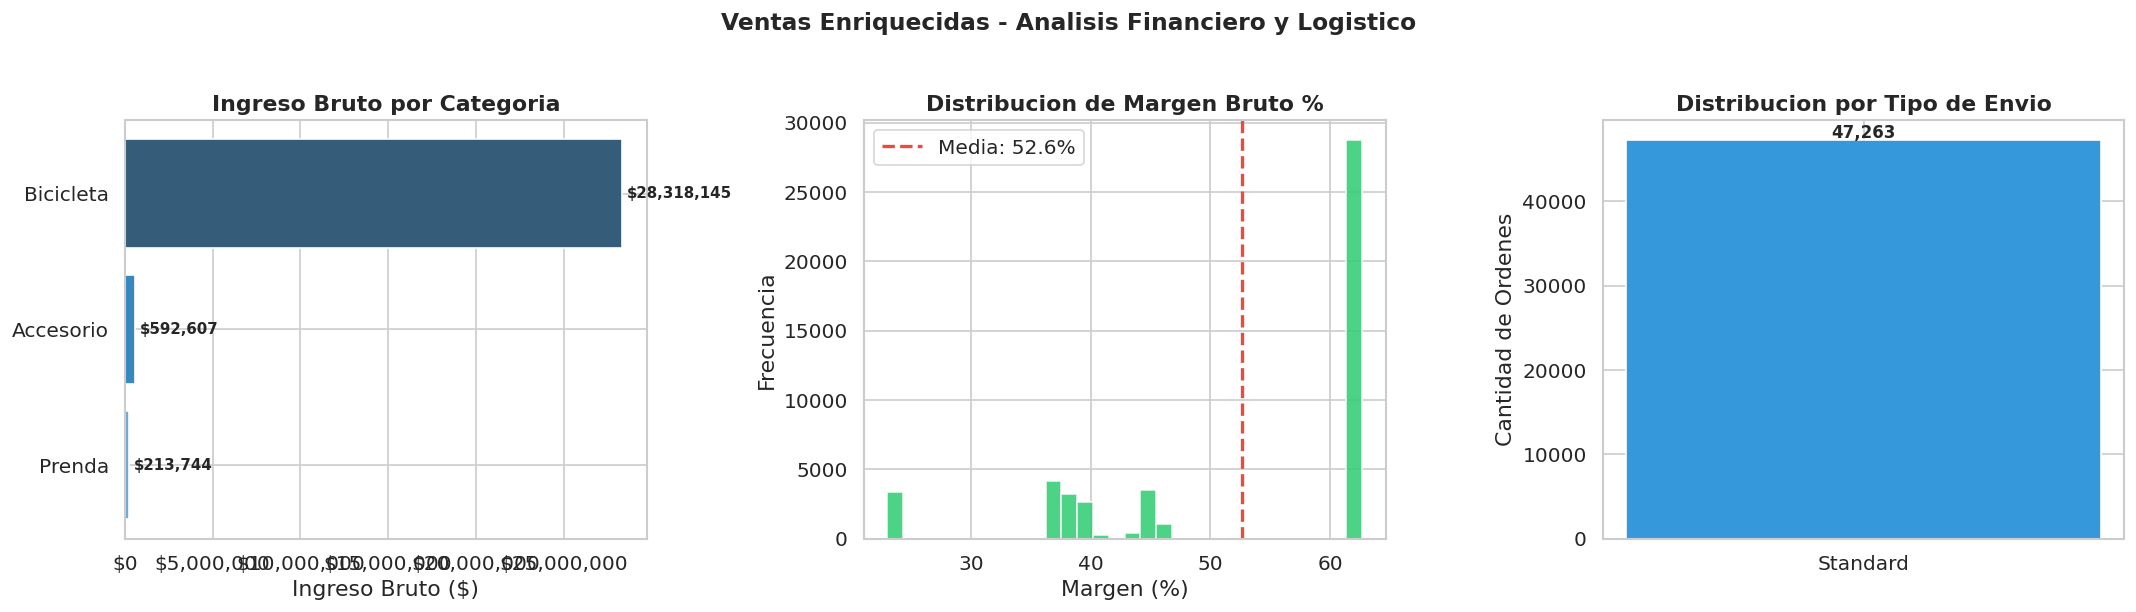

In [6]:
# ============================================================================
# GRAFICO: Distribucion financiera de ventas enriquecidas
# ============================================================================
df_ventas_pd = ventas.select(
    'Categoria', 'Ingreso_Bruto', 'Margen_Bruto', 'Ganancia_Neta',
    'Pct_Margen', 'Dias_Envio', 'Tipo_Envio'
).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Panel 1: Ingreso bruto por categoria --
cat_rev = df_ventas_pd.groupby('Categoria')['Ingreso_Bruto'].sum().sort_values()
colors_cat = sns.color_palette('Blues_d', len(cat_rev))
bars = axes[0].barh(cat_rev.index, cat_rev.values, color=colors_cat, edgecolor='white')
axes[0].set_xlabel('Ingreso Bruto ($)')
axes[0].set_title('Ingreso Bruto por Categoria', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, cat_rev.values):
    axes[0].text(bar.get_width() + cat_rev.max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')

# -- Panel 2: Distribucion de margen % --
axes[1].hist(df_ventas_pd['Pct_Margen'], bins=30, color='#2ecc71',
             edgecolor='white', alpha=0.85)
axes[1].axvline(df_ventas_pd['Pct_Margen'].mean(), color='#e74c3c',
                linestyle='--', linewidth=2, label=f'Media: {df_ventas_pd["Pct_Margen"].mean():.1f}%')
axes[1].set_xlabel('Margen (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de Margen Bruto %', fontweight='bold')
axes[1].legend()

# -- Panel 3: Tipo de envio --
envio_counts = df_ventas_pd['Tipo_Envio'].value_counts()
colors_envio = {'Express': '#2ecc71', 'Standard': '#3498db', 'Delayed': '#e74c3c'}
axes[2].bar(envio_counts.index, envio_counts.values,
            color=[colors_envio.get(x, '#95a5a6') for x in envio_counts.index],
            edgecolor='white')
axes[2].set_ylabel('Cantidad de Ordenes')
axes[2].set_title('Distribucion por Tipo de Envio', fontweight='bold')
for i, (lbl, val) in enumerate(zip(envio_counts.index, envio_counts.values)):
    axes[2].text(i, val + ventas_count * 0.005, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Ventas Enriquecidas - Analisis Financiero y Logistico',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Dominio Retail — Resumen de Ventas Mensuales

Agregacion temporal por **Year + Month + Categoria** para alimentar dashboards de seguimiento.

Metricas: ordenes, clientes unicos, unidades vendidas, ingreso bruto, ticket promedio, margen promedio.

In [7]:
# ============================================================================
# RESUMEN VENTAS MENSUALES: Agregacion temporal por categoria
# ----------------------------------------------------------------------------
# GroupBy: Year, Month, Categoria
# Metricas: ordenes, clientes, unidades, ingreso, ticket, margen promedio
# ============================================================================
t0 = datetime.now()

resumen = (
    ventas
    .withColumn('Year', F.year('FechaOrden'))
    .withColumn('Month', F.month('FechaOrden'))
    .groupBy('Year', 'Month', 'Categoria')
    .agg(
        F.countDistinct('NumeroOrden').alias('Total_Ordenes'),
        F.countDistinct('Cod_Cliente').alias('Clientes_Unicos'),
        F.sum('Cantidad').alias('Unidades_Vendidas'),
        F.round(F.sum('Ingreso_Bruto'), 2).alias('Ingreso_Bruto'),
        F.round(F.sum('Ganancia_Neta'), 2).alias('Ganancia_Neta'),
        F.round(F.avg('Ingreso_Bruto'), 2).alias('Ticket_Promedio'),
        F.round(F.avg('Pct_Margen'), 2).alias('Margen_Pct_Promedio'),
    )
    .orderBy('Year', 'Month')
)

resumen.write.mode('overwrite').parquet(cos_path('silver', 'resumen_ventas_mensuales'))
resumen_count = resumen.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'resumen_ventas_mensuales: {resumen_count:,} filas | {elapsed:.1f}s')
resumen.show(10, truncate=False)

resumen_ventas_mensuales: 65 filas | 7.4s
+----+-----+---------+-------------+---------------+-----------------+-------------+-------------+---------------+-------------------+
|Year|Month|Categoria|Total_Ordenes|Clientes_Unicos|Unidades_Vendidas|Ingreso_Bruto|Ganancia_Neta|Ticket_Promedio|Margen_Pct_Promedio|
+----+-----+---------+-------------+---------------+-----------------+-------------+-------------+---------------+-------------------+
|2010|12   |Bicicleta|14           |14             |14               |43421.04     |13289.79     |3101.5         |41.13              |
|2011|1    |Bicicleta|144          |144            |144              |469823.94    |139619.99    |3262.67        |40.31              |
|2011|2    |Bicicleta|144          |144            |144              |466334.93    |139075.08    |3238.44        |40.41              |
|2011|3    |Bicicleta|150          |150            |150              |485198.69    |142131.64    |3234.66        |39.91              |
|2011|4    |B

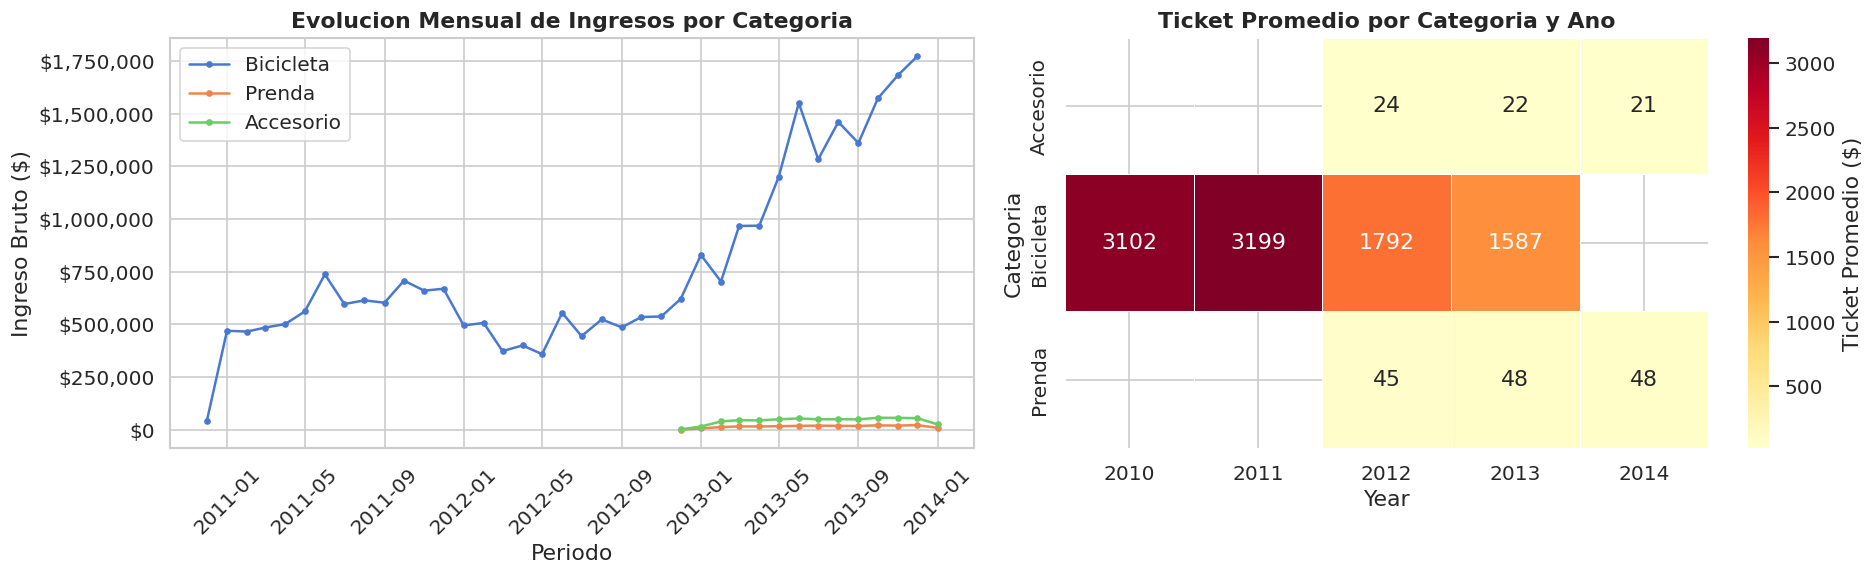

In [8]:
# ============================================================================
# GRAFICO: Evolucion temporal de ingresos por categoria
# ============================================================================
df_resumen_pd = resumen.toPandas()
df_resumen_pd['Periodo'] = pd.to_datetime(
    df_resumen_pd['Year'].astype(str) + '-' + df_resumen_pd['Month'].astype(str).str.zfill(2)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -- Panel 1: Linea temporal de ingreso por categoria --
for cat in df_resumen_pd['Categoria'].unique():
    subset = df_resumen_pd[df_resumen_pd['Categoria'] == cat].sort_values('Periodo')
    axes[0].plot(subset['Periodo'], subset['Ingreso_Bruto'],
                 marker='o', markersize=3, linewidth=1.5, label=cat)
axes[0].set_xlabel('Periodo')
axes[0].set_ylabel('Ingreso Bruto ($)')
axes[0].set_title('Evolucion Mensual de Ingresos por Categoria', fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)

# -- Panel 2: Heatmap de ticket promedio por Year x Categoria --
pivot = df_resumen_pd.pivot_table(
    values='Ticket_Promedio', index='Categoria', columns='Year', aggfunc='mean'
)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Ticket Promedio ($)'})
axes[1].set_title('Ticket Promedio por Categoria y Ano', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Dominio Retail — Rentabilidad por Producto

Agregacion por producto con metricas de volumen y rentabilidad.  
Permite identificar los productos **mas vendidos** vs **mas rentables** (no siempre coinciden).

In [9]:
# ============================================================================
# RENTABILIDAD POR PRODUCTO: Volumen + margen + precio promedio
# ============================================================================
t0 = datetime.now()

rentabilidad = (
    ventas
    .groupBy('Cod_Producto', 'Producto', 'Categoria')
    .agg(
        F.count('NumeroOrden').alias('Veces_Vendido'),
        F.sum('Cantidad').alias('Unidades_Totales'),
        F.round(F.sum('Ingreso_Bruto'), 2).alias('Revenue_Total'),
        F.round(F.sum('Ganancia_Neta'), 2).alias('Ganancia_Neta_Total'),
        F.round(F.avg('Pct_Margen'), 2).alias('Pct_Margen_Promedio'),
        F.round(F.avg('PrecioUnitario'), 2).alias('Precio_Promedio'),
    )
    .withColumn('Revenue_Por_Unidad',
        F.round(F.col('Revenue_Total') / F.col('Unidades_Totales'), 2))
)

rentabilidad.write.mode('overwrite').parquet(cos_path('silver', 'rentabilidad_producto'))
rent_count = rentabilidad.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'rentabilidad_producto: {rent_count:,} filas | {elapsed:.1f}s')

# -- Top 10 productos por revenue --
print('\nTop 10 productos por Revenue Total:')
rentabilidad.orderBy(F.desc('Revenue_Total')).show(10, truncate=25)

rentabilidad_producto: 147 filas | 5.4s

Top 10 productos por Revenue Total:
+------------+-------------------------+---------+-------------+----------------+-------------+-------------------+-------------------+---------------+------------------+
|Cod_Producto|                 Producto|Categoria|Veces_Vendido|Unidades_Totales|Revenue_Total|Ganancia_Neta_Total|Pct_Margen_Promedio|Precio_Promedio|Revenue_Por_Unidad|
+------------+-------------------------+---------+-------------+----------------+-------------+-------------------+-------------------+---------------+------------------+
|         312| Carretera: 150, roja, 48|Bicicleta|          337|             337|   1205876.99|          347534.62|              39.32|        3578.27|           3578.27|
|         310| Carretera: 150, roja, 62|Bicicleta|          336|             336|   1202298.72|          346503.36|              39.32|        3578.27|           3578.27|
|         313| Carretera: 150, roja, 52|Bicicleta|          302|    

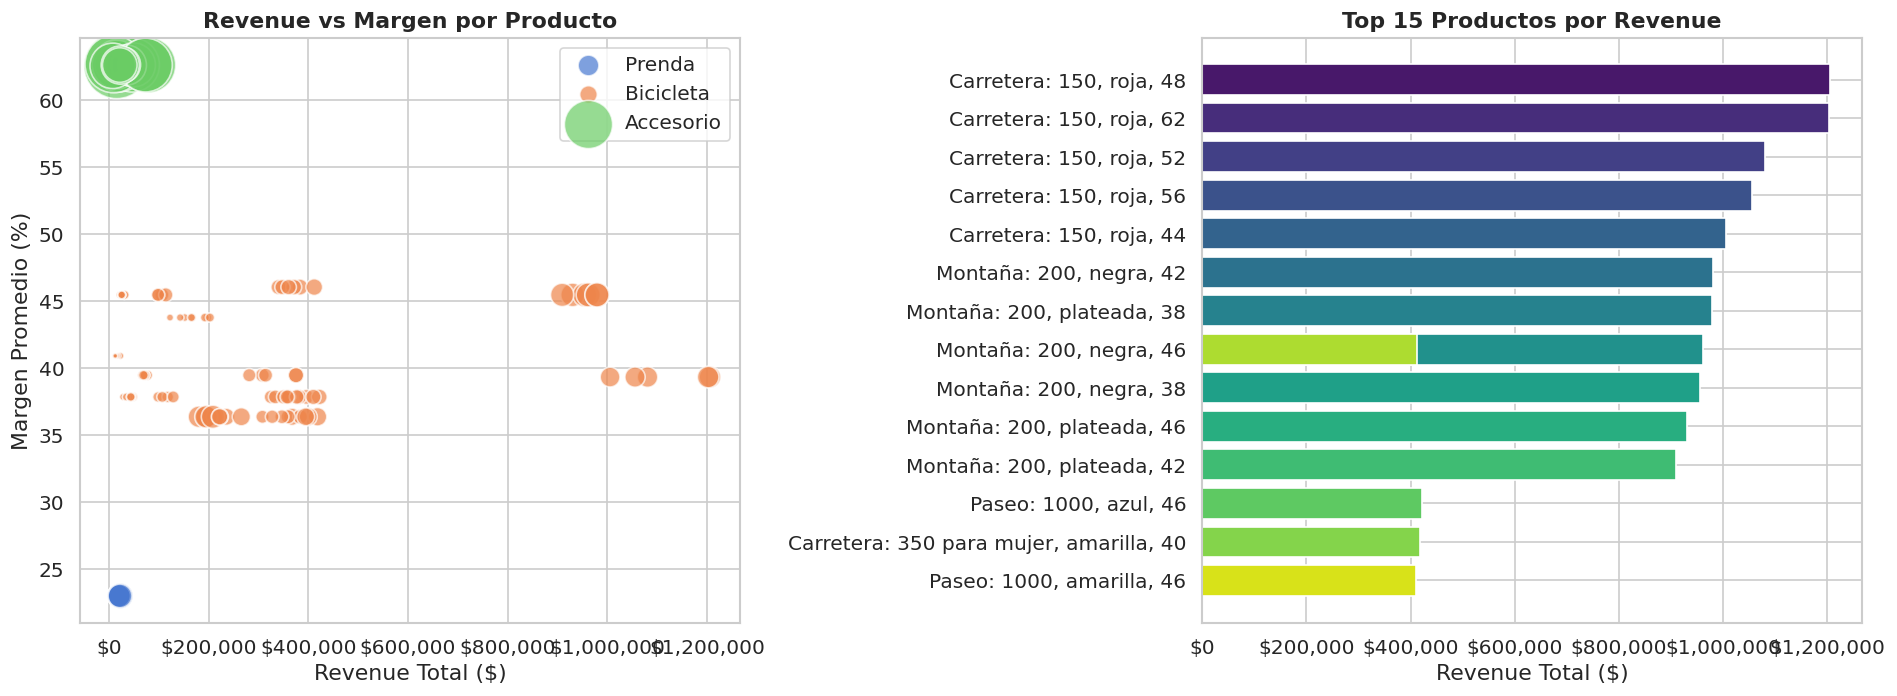

In [10]:
# ============================================================================
# GRAFICO: Top productos — Revenue vs Margen (scatter + barras)
# ============================================================================
df_rent_pd = rentabilidad.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Panel 1: Scatter Revenue vs Margen coloreado por Categoria --
for cat in df_rent_pd['Categoria'].unique():
    subset = df_rent_pd[df_rent_pd['Categoria'] == cat]
    axes[0].scatter(subset['Revenue_Total'], subset['Pct_Margen_Promedio'],
                    alpha=0.7, s=subset['Veces_Vendido'] * 0.5, label=cat, edgecolors='white')
axes[0].set_xlabel('Revenue Total ($)')
axes[0].set_ylabel('Margen Promedio (%)')
axes[0].set_title('Revenue vs Margen por Producto', fontweight='bold')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# -- Panel 2: Top 15 por revenue --
top15 = df_rent_pd.nlargest(15, 'Revenue_Total')
colors_bar = sns.color_palette('viridis', len(top15))
axes[1].barh(top15['Producto'], top15['Revenue_Total'], color=colors_bar, edgecolor='white')
axes[1].set_xlabel('Revenue Total ($)')
axes[1].set_title('Top 15 Productos por Revenue', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 7. Dominio Retail — Segmentacion de Clientes (RFM)

**Modelo RFM (Recency, Frequency, Monetary):** Tecnica clasica de segmentacion de clientes
basada en comportamiento de compra.

| Dimension | Calculo | Interpretacion |
|-----------|---------|----------------|
| **Recency** | Dias desde la ultima compra | Menor = mejor |
| **Frequency** | Cantidad de ordenes distintas | Mayor = mejor |
| **Monetary** | Suma total de ingreso bruto | Mayor = mejor |

**Scoring:** Cada dimension se divide en 5 quintiles (ntile).  
**Segmentos derivados:**

| Segmento | Regla |
|----------|-------|
| **VIP** | score_frecuencia <= 2 AND score_monetario <= 2 |
| **Frecuente** | score_frecuencia <= 3 |
| **En Riesgo** | score_recency >= 4 |
| **Regular** | Resto |

Ademas se calcula el **LTV Anualizado** (Lifetime Value proyectado a 365 dias).

In [11]:
# ============================================================================
# SEGMENTACION CLIENTES (RFM): Recency, Frequency, Monetary + LTV
# ----------------------------------------------------------------------------
# 1. Agregacion por cliente: metricas base
# 2. Scoring con quintiles (ntile 5) por cada dimension RFM
# 3. Etiquetado de segmentos de negocio
# 4. Calculo de LTV Anualizado
# ============================================================================
t0 = datetime.now()

# -- Fecha de referencia para Recency --
max_date = ventas.agg(F.max('FechaOrden')).collect()[0][0]
print(f'Fecha de referencia para Recency: {max_date}')

# -- Paso 1: Agregacion base por cliente --
clientes = (
    ventas
    .groupBy('Cod_Cliente')
    .agg(
        F.datediff(F.lit(max_date), F.max('FechaOrden')).alias('Recency'),
        F.countDistinct('NumeroOrden').alias('Frecuencia'),
        F.round(F.sum('Ingreso_Bruto'), 2).alias('Monetary'),
        F.round(F.avg('Ingreso_Bruto'), 2).alias('Ticket_Promedio'),
        F.round(F.sum('Ganancia_Neta'), 2).alias('Ganancia_Neta_Total'),
        F.min('FechaOrden').alias('Primera_Compra'),
        F.max('FechaOrden').alias('Ultima_Compra'),
        F.countDistinct('Cod_Producto').alias('Productos_Distintos'),
    )
    .withColumn('Dias_Como_Cliente',
        F.datediff(F.col('Ultima_Compra'), F.col('Primera_Compra')))
    .withColumn('LTV_Anualizado',
        F.when(F.col('Dias_Como_Cliente') > 0,
               F.round((F.col('Monetary') / F.col('Dias_Como_Cliente')) * 365, 2))
         .otherwise(F.col('Monetary')))
)

# -- Paso 2: Scoring RFM con quintiles --
for col_name, score_name, ascending in [
    ('Recency',    'score_recency',    True),     # menor recency = mejor
    ('Frecuencia', 'score_frecuencia', False),    # mayor frecuencia = mejor
    ('Monetary',   'score_monetario',  False),    # mayor monetary = mejor
]:
    w = Window.orderBy(F.col(col_name).asc() if ascending else F.col(col_name).desc())
    clientes = clientes.withColumn(score_name, F.ntile(5).over(w))

# -- Paso 3: Etiquetado de segmentos --
clientes = clientes.withColumn('Segmento',
    F.when((F.col('score_frecuencia') <= 2) & (F.col('score_monetario') <= 2), 'VIP')
     .when(F.col('score_frecuencia') <= 3, 'Frecuente')
     .when(F.col('score_recency') >= 4, 'En Riesgo')
     .otherwise('Regular'))

# -- Persistir --
clientes.write.mode('overwrite').parquet(cos_path('silver', 'segmentacion_clientes'))
clientes_count = clientes.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'segmentacion_clientes: {clientes_count:,} filas | {elapsed:.1f}s')

# -- Resumen por segmento --
print('\nDistribucion por Segmento:')
(clientes
    .groupBy('Segmento')
    .agg(
        F.count('*').alias('Clientes'),
        F.round(F.avg('Monetary'), 2).alias('Avg_Monetary'),
        F.round(F.avg('Frecuencia'), 1).alias('Avg_Frecuencia'),
        F.round(F.avg('Recency'), 1).alias('Avg_Recency'),
        F.round(F.avg('LTV_Anualizado'), 2).alias('Avg_LTV'),
    )
    .orderBy(F.desc('Avg_Monetary'))
    .show(truncate=False)
)

Fecha de referencia para Recency: 2014-01-28 00:00:00


26/04/12 19:06:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:06:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:06:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:06:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:06:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:06:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 1

segmentacion_clientes: 17,555 filas | 8.2s

Distribucion por Segmento:


26/04/12 19:06:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:06:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:06:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:06:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:06:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:06:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 1

+---------+--------+------------+--------------+-----------+-------+
|Segmento |Clientes|Avg_Monetary|Avg_Frecuencia|Avg_Recency|Avg_LTV|
+---------+--------+------------+--------------+-----------+-------+
|VIP      |4989    |4465.57     |2.2           |173.1      |3749.68|
|En Riesgo|4976    |719.39      |1.0           |337.0      |719.39 |
|Frecuente|5544    |440.44      |1.5           |83.3       |654.64 |
|Regular  |2046    |402.85      |1.0           |170.1      |402.85 |
+---------+--------+------------+--------------+-----------+-------+



26/04/12 19:07:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:07:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:07:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:07:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:07:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 19:07:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/12 1

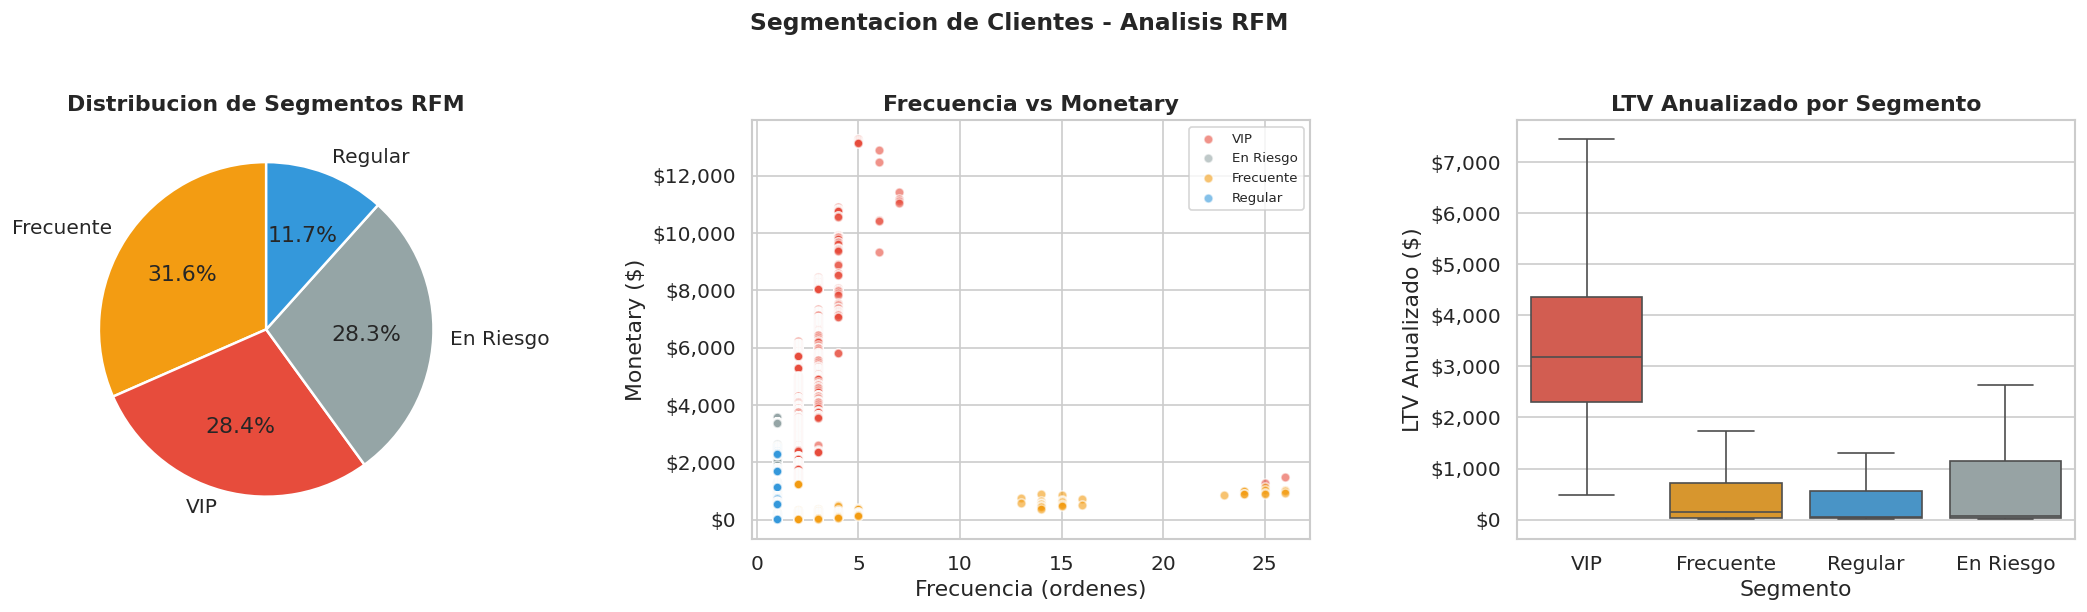

In [12]:
# ============================================================================
# GRAFICO: Segmentacion RFM — Distribucion + Scatter
# ============================================================================
df_cli_pd = clientes.select(
    'Segmento', 'Recency', 'Frecuencia', 'Monetary', 'LTV_Anualizado'
).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Panel 1: Pie chart segmentos --
seg_counts = df_cli_pd['Segmento'].value_counts()
colors_seg = {'VIP': '#e74c3c', 'Frecuente': '#f39c12', 'Regular': '#3498db', 'En Riesgo': '#95a5a6'}
axes[0].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            colors=[colors_seg.get(s, '#bdc3c7') for s in seg_counts.index],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Distribucion de Segmentos RFM', fontweight='bold')

# -- Panel 2: Scatter Frecuencia vs Monetary coloreado por segmento --
for seg in df_cli_pd['Segmento'].unique():
    subset = df_cli_pd[df_cli_pd['Segmento'] == seg]
    axes[1].scatter(subset['Frecuencia'], subset['Monetary'],
                    alpha=0.6, s=30, label=seg,
                    color=colors_seg.get(seg, '#bdc3c7'), edgecolors='white')
axes[1].set_xlabel('Frecuencia (ordenes)')
axes[1].set_ylabel('Monetary ($)')
axes[1].set_title('Frecuencia vs Monetary', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# -- Panel 3: Box plot de LTV por segmento --
seg_order = ['VIP', 'Frecuente', 'Regular', 'En Riesgo']
df_cli_pd['Segmento'] = pd.Categorical(df_cli_pd['Segmento'], categories=seg_order, ordered=True)
df_cli_sorted = df_cli_pd.sort_values('Segmento')
palette_box = [colors_seg[s] for s in seg_order if s in df_cli_pd['Segmento'].unique()]
sns.boxplot(data=df_cli_sorted, x='Segmento', y='LTV_Anualizado',
            palette=palette_box, ax=axes[2], showfliers=False)
axes[2].set_ylabel('LTV Anualizado ($)')
axes[2].set_title('LTV Anualizado por Segmento', fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Segmentacion de Clientes - Analisis RFM',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Dominio Mineria — Produccion por Operador

Agregacion por operador para medir productividad individual.  
Metricas: ore total extraido, desperdicio, eficiencia personal, promedio por registro.

In [13]:
# ============================================================================
# PRODUCCION POR OPERADOR: Productividad individual de mineria
# ============================================================================
t0 = datetime.now()

prod_op = (
    bronze['mine']
    .drop('_bronze_ingested_at', '_bronze_source_file')
    .groupBy('OperatorID', 'FirstName', 'LastName', 'Country')
    .agg(
        F.sum('TotalOreMined').alias('Total_Ore'),
        F.sum('TotalWasted').alias('Total_Waste'),
        F.count('*').alias('Records'),
        F.round(F.avg('TotalOreMined'), 2).alias('Avg_Ore_Per_Record'),
        F.round(F.avg('TotalWasted'), 2).alias('Avg_Waste_Per_Record'),
    )
    .withColumn('Efficiency_Pct',
        F.round(F.col('Total_Ore') / (F.col('Total_Ore') + F.col('Total_Waste')) * 100, 2))
    .withColumn('FullName', F.concat_ws(' ', 'FirstName', 'LastName'))
)

prod_op.write.mode('overwrite').parquet(cos_path('silver', 'produccion_operador'))
prod_op_count = prod_op.count()
elapsed = (datetime.now() - t0).total_seconds()

print(f'produccion_operador: {prod_op_count:,} filas | {elapsed:.1f}s')
print(f'   Paises: {prod_op.select("Country").distinct().count()}')

print('\nTop 10 operadores por Total Ore:')
prod_op.orderBy(F.desc('Total_Ore')).select(
    'FullName', 'Country', 'Total_Ore', 'Total_Waste', 'Efficiency_Pct', 'Records'
).show(10, truncate=False)

produccion_operador: 9,132 filas | 5.6s
   Paises: 6

Top 10 operadores por Total Ore:


+-----------------+-------+----------+------------------+--------------+-------+
|FullName         |Country|Total_Ore |Total_Waste       |Efficiency_Pct|Records|
+-----------------+-------+----------+------------------+--------------+-------+
|Randall Dominguez|France |13109.75  |1048.78           |92.59         |5      |
|Nichole Nara     |France |13109.75  |1048.78           |92.59         |5      |
|Adriana Gonzalez |France |13109.75  |1048.78           |92.59         |5      |
|Brandi Gill      |France |13084.75  |1046.78           |92.59         |5      |
|Francisco Sara   |France |13084.75  |1046.78           |92.59         |5      |
|Margaret He      |France |13084.75  |1046.78           |92.59         |5      |
|Kaitlyn Henderson|France |13084.75  |1046.78           |92.59         |5      |
|Rosa Hu          |France |13084.75  |1046.78           |92.59         |5      |
|Brad She         |France |13084.75  |1046.78           |92.59         |5      |
|Maurice Shan     |France |1

---
## 9. Dominio Mineria — Eficiencia Minera + Produccion por Pais

**Eficiencia Minera:** Analisis por camion y proyecto.  
`Efficiency_Pct = Total_Ore / (Total_Ore + Total_Waste) * 100`

**Produccion por Pais:** Vision macro de la operacion minera por geografia.

In [14]:
# ============================================================================
# EFICIENCIA MINERA: Analisis por camion y proyecto
# ============================================================================
t0 = datetime.now()

eficiencia = (
    bronze['factmine']
    .drop('_bronze_ingested_at', '_bronze_source_file')
    .groupBy('TruckID', 'ProjectID')
    .agg(
        F.sum('TotalOreMined').alias('Total_Ore'),
        F.sum('TotalWasted').alias('Total_Waste'),
        F.count('*').alias('Trips'),
        F.round(F.avg('TotalOreMined'), 2).alias('Avg_Ore_Per_Trip'),
    )
    .withColumn('Efficiency_Pct',
        F.round(F.col('Total_Ore') / (F.col('Total_Ore') + F.col('Total_Waste')) * 100, 2))
    .withColumn('Ore_Waste_Ratio',
        F.round(F.col('Total_Ore') / F.col('Total_Waste'), 2))
)

eficiencia.write.mode('overwrite').parquet(cos_path('silver', 'eficiencia_minera'))
ef_count = eficiencia.count()
elapsed_ef = (datetime.now() - t0).total_seconds()

print(f'eficiencia_minera: {ef_count:,} filas | {elapsed_ef:.1f}s')
eficiencia.orderBy(F.desc('Efficiency_Pct')).show(10, truncate=False)

# ============================================================================
# PRODUCCION POR PAIS: Vision geografica macro
# ============================================================================
t0 = datetime.now()

prod_pais = (
    bronze['mine']
    .drop('_bronze_ingested_at', '_bronze_source_file')
    .groupBy('Country')
    .agg(
        F.sum('TotalOreMined').alias('Total_Ore'),
        F.sum('TotalWasted').alias('Total_Waste'),
        F.countDistinct('OperatorID').alias('Operators'),
        F.countDistinct('TruckID').alias('Trucks'),
        F.count('*').alias('Total_Records'),
    )
    .withColumn('Efficiency_Pct',
        F.round(F.col('Total_Ore') / (F.col('Total_Ore') + F.col('Total_Waste')) * 100, 2))
    .withColumn('Ore_Per_Operator',
        F.round(F.col('Total_Ore') / F.col('Operators'), 2))
)

prod_pais.write.mode('overwrite').parquet(cos_path('silver', 'produccion_por_pais'))
pp_count = prod_pais.count()
elapsed_pp = (datetime.now() - t0).total_seconds()

print(f'\nproduccion_por_pais: {pp_count:,} filas | {elapsed_pp:.1f}s')
prod_pais.orderBy(F.desc('Total_Ore')).show(truncate=False)

eficiencia_minera: 7 filas | 4.6s
+-------+---------+------------------+------------------+-----+----------------+--------------+---------------+
|TruckID|ProjectID|Total_Ore         |Total_Waste       |Trips|Avg_Ore_Per_Trip|Efficiency_Pct|Ore_Waste_Ratio|
+-------+---------+------------------+------------------+-----+----------------+--------------+---------------+
|346    |10       |16999.949999999997|1359.9959999999999|5    |3399.99         |92.59         |12.5           |
|346    |4        |10199.97          |815.9975999999999 |3    |3399.99         |92.59         |12.5           |
|346    |6        |6799.98           |543.9984          |2    |3399.99         |92.59         |12.5           |
|346    |9        |95199.72000000002 |7615.977600000004 |28   |3399.99         |92.59         |12.5           |
|346    |7        |6799.98           |543.9984          |2    |3399.99         |92.59         |12.5           |
|346    |8        |10199.97          |815.9975999999999 |3    |3399.99


produccion_por_pais: 6 filas | 4.9s


+--------------+------------------+------------------+---------+------+-------------+--------------+----------------+
|Country       |Total_Ore         |Total_Waste       |Operators|Trucks|Total_Records|Efficiency_Pct|Ore_Per_Operator|
+--------------+------------------+------------------+---------+------+-------------+--------------+----------------+
|United States |8999859.530800585 |719988.7783000311 |3569     |116   |4907         |92.59         |2521.68         |
|Australia     |8852050.004400235 |708164.0202000273 |2155     |116   |4472         |92.59         |4107.68         |
|United Kingdom|3282842.6609001183|262627.41789999924|1032     |113   |1858         |92.59         |3181.05         |
|Germany       |2808514.34820009  |224681.1522       |904      |116   |1600         |92.59         |3106.76         |
|France        |2553575.7143000904|204286.06199999983|816      |113   |1444         |92.59         |3129.38         |
|Canada        |1821302.3921000122|145704.19389999995|65

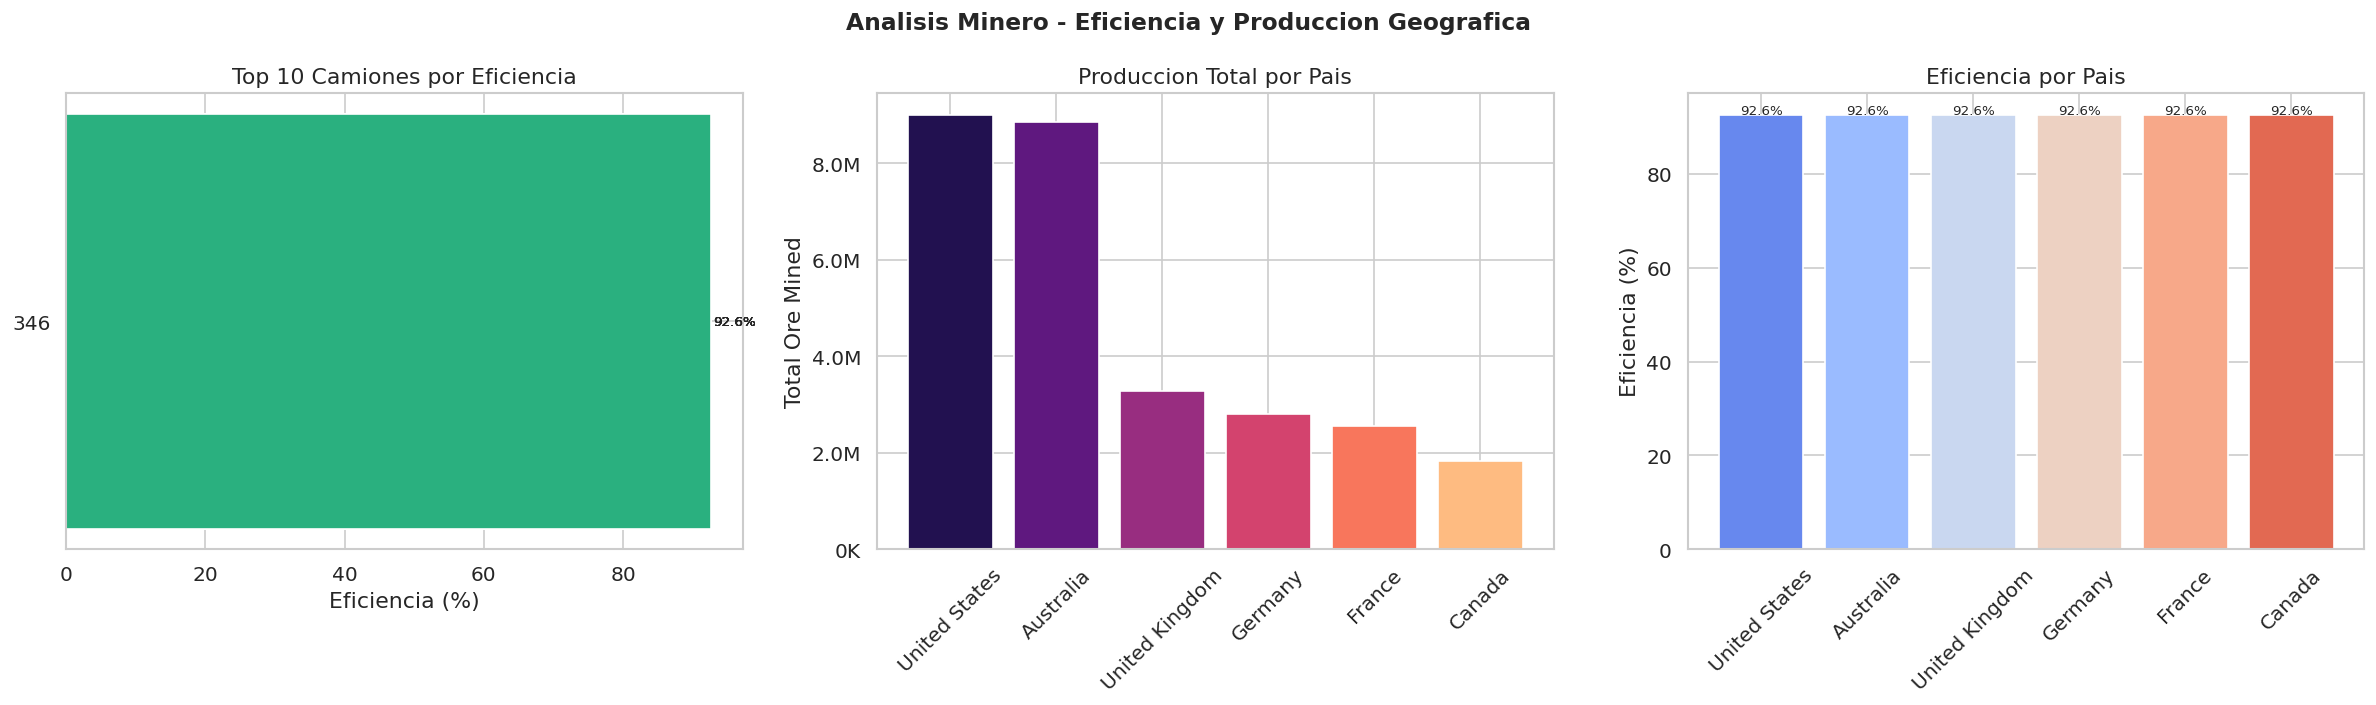

In [15]:
# --- Visualizacion: Eficiencia minera y produccion por pais ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Analisis Minero - Eficiencia y Produccion Geografica', fontsize=14, fontweight='bold')

# 1) Top 10 camiones por eficiencia
ef_pd = eficiencia.orderBy(F.desc('Efficiency_Pct')).limit(10).toPandas()
bars1 = axes[0].barh(ef_pd['TruckID'].astype(str), ef_pd['Efficiency_Pct'], color=sns.color_palette('viridis', 10))
axes[0].set_xlabel('Eficiencia (%)')
axes[0].set_title('Top 10 Camiones por Eficiencia')
axes[0].invert_yaxis()
for bar, val in zip(bars1, ef_pd['Efficiency_Pct']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8)

# 2) Produccion total por pais
pp_pd = prod_pais.orderBy(F.desc('Total_Ore')).toPandas()
colors_pp = sns.color_palette('magma', len(pp_pd))
bars2 = axes[1].bar(pp_pd['Country'], pp_pd['Total_Ore'], color=colors_pp)
axes[1].set_ylabel('Total Ore Mined')
axes[1].set_title('Produccion Total por Pais')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

# 3) Eficiencia por pais
axes[2].bar(pp_pd['Country'], pp_pd['Efficiency_Pct'], color=sns.color_palette('coolwarm', len(pp_pd)))
axes[2].set_ylabel('Eficiencia (%)')
axes[2].set_title('Eficiencia por Pais')
axes[2].tick_params(axis='x', rotation=45)
for i, (c, v) in enumerate(zip(pp_pd['Country'], pp_pd['Efficiency_Pct'])):
    axes[2].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

---

## 10. Persistencia Final y Resumen de Resultados

**Capa Silver completada.** Resumen consolidado de todas las tablas generadas, tiempos de procesamiento y metricas de calidad.

| # | Tabla Silver | Descripcion | Fuentes Bronze |
|---|---|---|---|
| 1 | `catalogo_productos` | Catalogo dimensional completo | producto, subcategoria, categoria |
| 2 | `ventas_enriquecidas` | Fact table con metricas calculadas | ventasinternet + catalogo |
| 3 | `resumen_ventas_mensuales` | Agregacion temporal | ventas_enriquecidas |
| 4 | `rentabilidad_producto` | Analisis de rentabilidad | ventas_enriquecidas |
| 5 | `segmentacion_clientes` | Segmentacion RFM + LTV | ventas_enriquecidas |
| 6 | `produccion_operador` | KPIs por operador minero | mine |
| 7 | `eficiencia_minera` | Eficiencia Truck/Project | factmine |
| 8 | `produccion_por_pais` | Vision geografica macro | mine |

,Tabla,Filas,Columnas,Estado
0,catalogo_productos,319,5,OK
1,ventas_enriquecidas,"47,263",28,OK
2,resumen_ventas_mensuales,65,10,OK
3,rentabilidad_producto,147,10,OK
4,segmentacion_clientes,"17,555",15,OK
5,produccion_operador,"9,132",11,OK
6,eficiencia_minera,7,8,OK
7,produccion_por_pais,6,8,OK


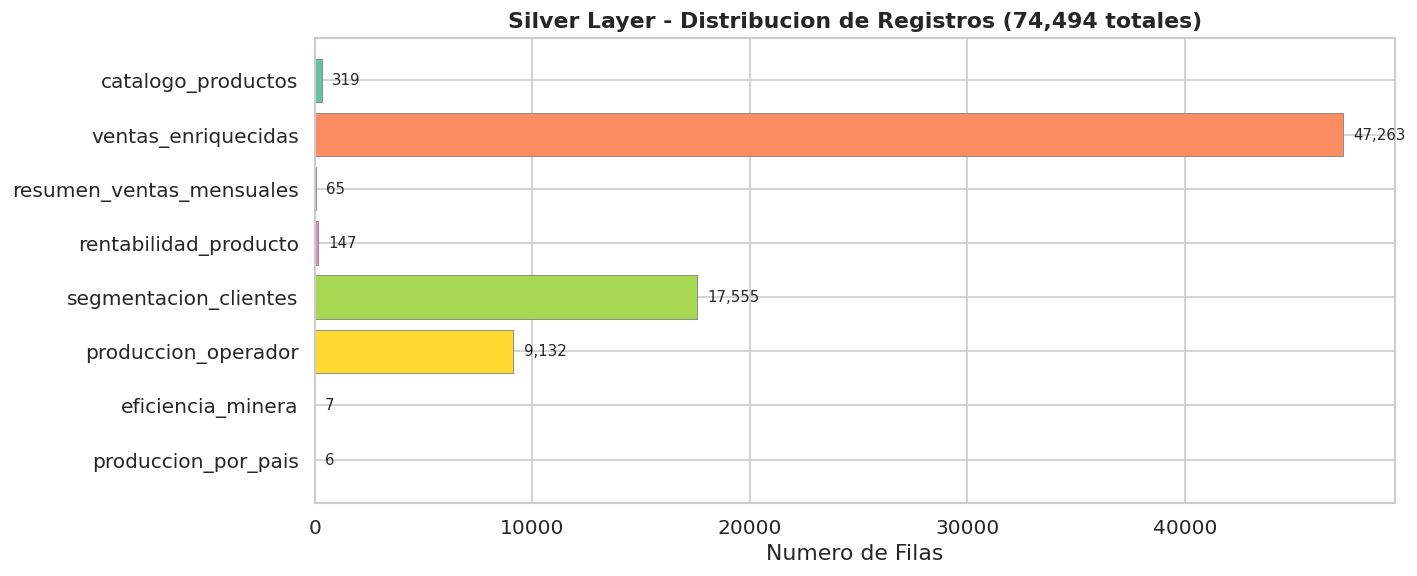


------------------------------------------------------------
  SILVER LAYER COMPLETADA
  Tablas generadas: 8
  Total registros:  74,494
------------------------------------------------------------

SparkSession finalizada.


In [16]:
# ============================================================================
# RESUMEN FINAL: Inventario de tablas Silver producidas
# ============================================================================

# Leer cada tabla silver desde COS para validacion
silver_tables = {
    'catalogo_productos': catalogo,
    'ventas_enriquecidas': ventas,
    'resumen_ventas_mensuales': resumen,
    'rentabilidad_producto': rentabilidad,
    'segmentacion_clientes': clientes,
    'produccion_operador': prod_op,
    'eficiencia_minera': eficiencia,
    'produccion_por_pais': prod_pais,
}

summary_rows = []
total_rows = 0
for name, df in silver_tables.items():
    cnt = df.count()
    cols = len(df.columns)
    total_rows += cnt
    summary_rows.append({
        'Tabla': name,
        'Filas': f'{cnt:,}',
        'Columnas': cols,
        'Estado': 'OK'
    })

summary_df = pd.DataFrame(summary_rows)
styled = (
    summary_df.style
    .set_caption(f'Silver Layer - {len(silver_tables)} tablas | {total_rows:,} filas totales')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#1a5276')]},
        {'selector': 'th', 'props': [('background-color', '#2e86c1'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ])
    .apply(lambda x: ['background-color: #d5f5e3' if v == 'OK' else '' for v in x], subset=['Estado'])
)
display(styled)

# --- Grafico resumen ---
fig, ax = plt.subplots(figsize=(12, 5))
names = [r['Tabla'] for r in summary_rows]
counts = [int(r['Filas'].replace(',', '')) for r in summary_rows]
colors = sns.color_palette('Set2', len(names))
bars = ax.barh(names, counts, color=colors, edgecolor='gray', linewidth=0.5)
ax.set_xlabel('Numero de Filas')
ax.set_title(f'Silver Layer - Distribucion de Registros ({total_rows:,} totales)', fontweight='bold')
ax.invert_yaxis()
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

separator = '-' * 60
print(f'\n{separator}')
print(f'  SILVER LAYER COMPLETADA')
print(f'  Tablas generadas: {len(silver_tables)}')
print(f'  Total registros:  {total_rows:,}')
print(f'{separator}')

# Liberar cache
ventas.unpersist()
spark.stop()
print('\nSparkSession finalizada.')